<a href="https://colab.research.google.com/github/dtn2/BIFX546_diabetes-indicators/blob/main/notebooks/EDA_diabetes_indicators.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Diabetes Health Indicators Dataset Analysis

---





Name: Duong Nguyen

Course: BIFX 546 — Machine Learning for Bioinformatics, Spring 2026

Instructor: Dr. Sarangan (Ravi) Ravichandran

Date: 18 March 2026

Dataset name and source URL: Diabetes Health Indicators Dataset: https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset


---



# Project's  Goal

The project aims to develop an interpretable predictive model for diabetes status and to identify key risk factors associated with diabetes. The results are expected to provide insight into which variables contribute most to diabetes risk and how different health indicators relate to one another.

# Dataset Introduction and Import

The dataset is derived from The Behavioral Risk Factor Surveillance System (BRFSS), an annual health survey conducted by the CDC that collects information on health-related behaviors, chronic conditions, and demographic factors across United States. For this project, a clean subset of 253,680 responses from the 2015 survey is used. The dataset contains 21 feature variables related to lifestyle, clinical indicators, and demographics, along with a binary target variable where 0 indicates no diabetes and 1 indicates diabetes or prediabetes.

This dataset was chosen because it is large, well-structured, and already cleaned, allowing more focus on exploratory data analysis, statistical inference, and modeling rather than extensive processing. The variety of features also enables multiple analytical approaches aligned with the project objectives.


In [ ]:
import kagglehub
import pandas as pd

# download dataset
path = kagglehub.dataset_download("alexteboul/diabetes-health-indicators-dataset")

print("Path to dataset files:", path)

# load csv file
df = pd.read_csv(path + "/diabetes_binary_health_indicators_BRFSS2015.csv")

df.head()

Using Colab cache for faster access to the 'diabetes-health-indicators-dataset' dataset.
Path to dataset files: /kaggle/input/diabetes-health-indicators-dataset


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


#Dataset Overview

## Rows and Columns of Data

In [ ]:
print(df.shape)
print(f"The table has {len(df)} rows and {len(df.columns)} columns.")


(253680, 22)
The table has 253680 rows and 22 columns.


## Data Types

In [ ]:
print(df.dtypes)
pd.value_counts(df.dtypes)

df.describe().T

Diabetes_binary         float64
HighBP                  float64
HighChol                float64
CholCheck               float64
BMI                     float64
Smoker                  float64
Stroke                  float64
HeartDiseaseorAttack    float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
HvyAlcoholConsump       float64
AnyHealthcare           float64
NoDocbcCost             float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Sex                     float64
Age                     float64
Education               float64
Income                  float64
dtype: object


/tmp/ipykernel_169/253282500.py:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(df.dtypes)


,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,253680.0,0.139333,0.346294,0.0,0.0,0.0,0.0,1.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0


All variables currently stored as float64. The dataset is numerically clean, but data types do not reflect true variable meaning.

Binary variables (0–1) represent yes/no health indicators:
HighBP, Smoker, Stroke, Sex, etc.
=> change to int

Categorical / ordinal variables: These are ordered categories, not true numeric values:
Age (1–13 → age groups);
Education (1–6);
Income (1–8);
GenHlth (1–5);
=> Change to category

Continuous / count variables: These contain meaningful numeric differences:
BMI (continuous);
MentHlth, PhysHlth (0–30 days)
=> leave as float

In [ ]:
# Binary → int
binary_cols = [
    'Diabetes_binary','HighBP','HighChol','CholCheck','Smoker',
    'Stroke','HeartDiseaseorAttack','PhysActivity','Fruits',
    'Veggies','HvyAlcoholConsump','AnyHealthcare','NoDocbcCost',
    'DiffWalk','Sex'
]

df[binary_cols] = df[binary_cols].astype(int)

# Categorical → category
cat_cols = ['Age','Education','Income','GenHlth']
df[cat_cols] = df[cat_cols].astype('category')

# Leave these as float
# BMI, MentHlth, PhysHlth

pd.value_counts(df.dtypes)

/tmp/ipykernel_169/1011613379.py:18: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(df.dtypes)


,count
int64,15
float64,3
category,1
category,1
category,1
category,1


I converted binary variables to integers, retained continuous variables as numeric, and encoded categorical variables such as age, income, and education appropriately. This ensures the dataset reflects the true meaning of each feature and improves model interpretability

## Missing Value Check

In [ ]:
# Missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64


No missing values were found across all variables, indicating that the dataset is fully populated. This is important because missing values can bias results or require imputation strategies that may introduce uncertainty. Since no missing data were present, no imputation or row removal was necessary.

## Duplicate Rows Check

In [ ]:
duplicates = df.duplicated().sum()
total = len(df)

print(f"Duplicate rows: {duplicates} ({duplicates/total:.2%})")

Duplicate rows: 24206 (9.54%)


Approximately 9.5% duplicate rows in the dataset, which could bias both statistical analysis and model performance. Failing to remove duplicates could lead to overrepresentation of certain observations and artificially inflated model performance.

However, since this is survey data with many categorical variables, these duplicates likely represent different individuals with identical responses rather than data errors. Therefore, the duplicates were retained to preserve the dataset’s integrity

## Outlier Inspection


The initial review of summary statistics and distributions using df.describe() indicated potential outliers in BMI variable with extreme values (up to 98). The BMI distribution is right-skewed with a long tail, indicating the presence of extreme values. However, since this is a real-world health dataset, these values likely represent individuals with severe obesity, so they were retained for analysis for now but will be monitored during modeling.

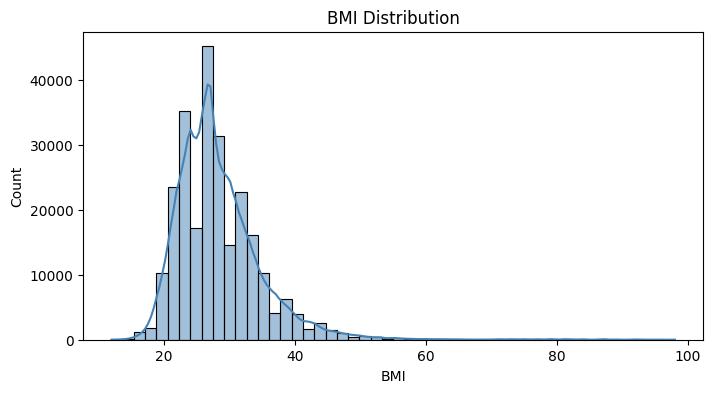

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.histplot(df['BMI'], bins=50, kde=True, color='steelblue')
plt.title('BMI Distribution')
plt.xlabel('BMI')
plt.show()

In [ ]:
print("BMI Stats:")
print("Min:", df['BMI'].min())
print("Max:", df['BMI'].max())
print("Mean:", df['BMI'].mean().round(2))
total = len(df)

# How many rows have BMI > 60?
print(f"\nRows with BMI > 60: {(df['BMI'] > 60).sum()} ({duplicates/total:.2%})")

BMI Stats:
Min: 12.0
Max: 98.0
Mean: 28.38

Rows with BMI > 60: 805 (9.54%)


## Class Imbalance Identification

In [ ]:
df['Diabetes_binary'].value_counts()
df['Diabetes_binary'].value_counts().to_frame('count').assign(percent=lambda x: x['count']/x['count'].sum())

,count,percent
Diabetes_binary,,
0,218334,0.860667
1,35346,0.139333


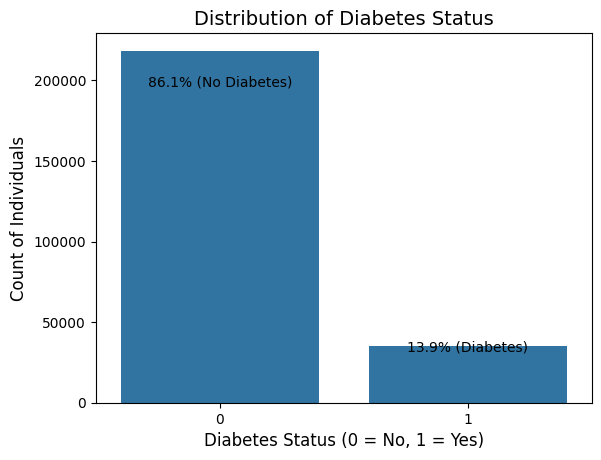

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="Diabetes_binary", data=df)

# Titles and labels
plt.title("Distribution of Diabetes Status", fontsize=14)
plt.xlabel("Diabetes Status (0 = No, 1 = Yes)", fontsize=12)
plt.ylabel("Count of Individuals", fontsize=12)

# Annotation: show imbalance %
counts = df['Diabetes_binary'].value_counts(normalize=True)
plt.text(0, df['Diabetes_binary'].value_counts()[0] * 0.9,
         f"{counts[0]:.1%} (No Diabetes)", ha='center')
plt.text(1, df['Diabetes_binary'].value_counts()[1] * 0.9,
         f"{counts[1]:.1%} (Diabetes)", ha='center')

plt.show()

I examined the distribution of the target variable (Diabetes_binary) and found a strong class imbalance (~86% non-diabetic vs. ~14% diabetic). This is important because imbalance can bias predictive models toward the majority class. This issue will be addressed in later modeling steps using techniques such as class weighting or resampling.

In [ ]:
#from sklearn.linear_model import LogisticRegression

#model = LogisticRegression(class_weight='balanced')

# Preliminary EDA

## Heatmap

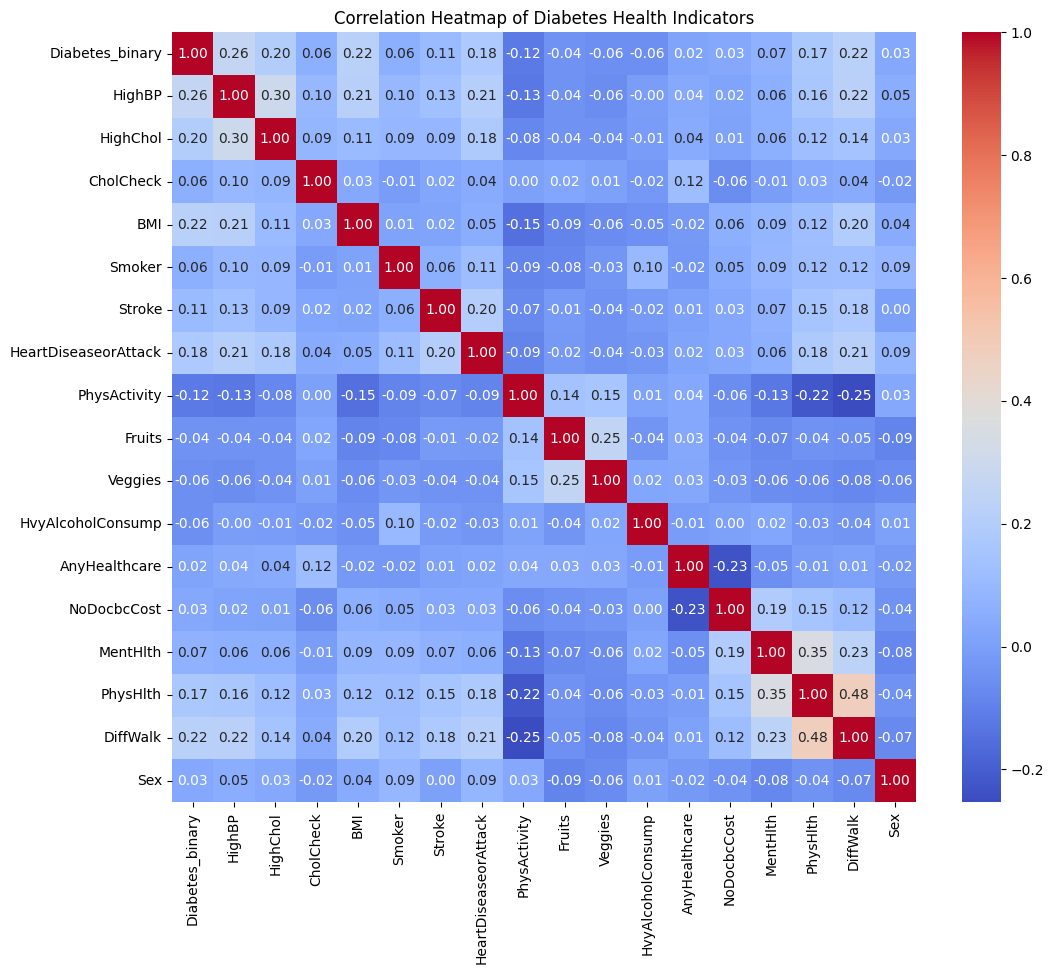

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Diabetes Health Indicators")
plt.show()

The heatmap shows that high blood pressure, BMI, and difficulty walking have the strongest positive relationships with diabetes, while physical activity shows a negative relationship. However, heatmap does not covered categorized variables like age, income, etc.
Overall, from the map there is no single variable dominates, suggesting diabetes is influenced by multiple factors.

## BMI vs Diabetes Status

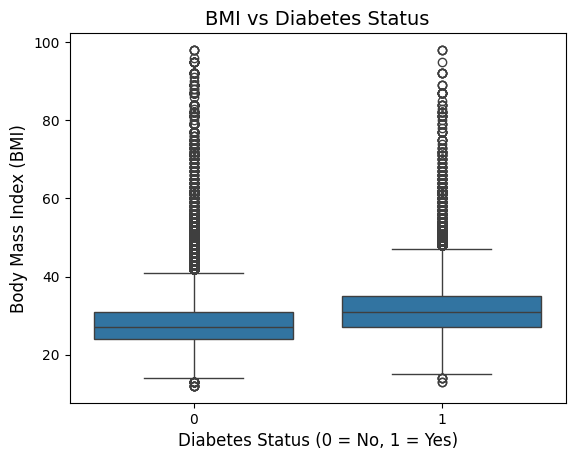

In [ ]:
sns.boxplot(x="Diabetes_binary", y="BMI", data=df)
# Titles and labels
plt.title("BMI vs Diabetes Status", fontsize=14)
plt.xlabel("Diabetes Status (0 = No, 1 = Yes)", fontsize=12)
plt.ylabel("Body Mass Index (BMI)", fontsize=12)
plt.show()

The boxplot shows that individuals with diabetes have a higher median BMI and a wider distribution compared to non-diabetic individuals. This suggests a strong positive association between BMI and diabetes. However, there is still overlap between groups, indicating that BMI alone is not sufficient for prediction

## Age Vs Diabetes status

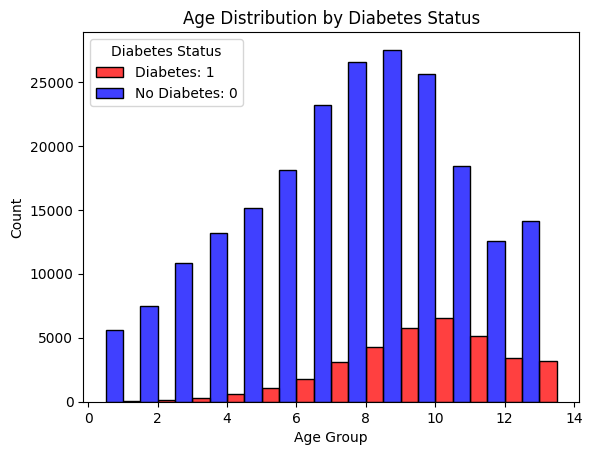

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(
    data=df,
    x="Age",
    hue="Diabetes_binary",
    bins=13,
    palette={0: "blue", 1: "red"},
    multiple="dodge"   # separates bars instead of overlapping
)

plt.title("Age Distribution by Diabetes Status")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.legend(title="Diabetes Status", labels=["Diabetes: 1", "No Diabetes: 0"])
plt.show()

The age distribution shows that diabetes prevalence increases with age. Most diabetic cases are concentrated in higher age groups, while younger groups have very few cases. This suggests that age is an important risk factor, although it does not fully explain diabetes on its own.

# Early insights and next steps

The goal of this project is to predict diabetes status using health indicators and identify the most important risk factors. From the exploratory data analysis, several key patterns emerged that directly inform this objective.

* First, the dataset is highly imbalanced (~85% non-diabetic vs. ~15% diabetic),
which highlights the need for careful model evaluation beyond simple accuracy.

* Second, BMI shows a clear positive association with diabetes, with diabetic individuals having a higher median BMI and more extreme values.

* Third, age demonstrates a strong trend, where diabetes prevalence increases across higher age groups.


Together, these findings suggest that both physiological factors (BMI) and demographic factors (age) are important predictors, but no single variable fully explains diabetes risk.


Based on these insights, the next step is to move into predictive modeling.

* I will begin with logistic regression to model the probability of diabetes, using appropriate preprocessing such as one-hot encoding for categorical variables and retaining continuous variables as numeric.

* To address class imbalance, I will use class weighting and evaluate model performance using recall, precision, and F1-score, with particular focus on correctly identifying diabetic cases.

* I also plan to compare this baseline model with resampling approaches such as SMOTE.

* Additionally, I will examine model coefficients to interpret feature importance and assess how variables like BMI and age contribute to prediction. If needed, I will refine the model by handling outliers (e.g., BMI) and exploring interactions between variables.

